# Milestone 1 Project: Customer Churn Prediction

## Problem Statement

Telecom companies lose significant revenue when customers cancel 
their subscriptions (churn). This project builds a model to 
predict which customers are likely to churn, based on their 
account information, services used, and billing details. The 
predicted churn probability supports the retention team: 
customers flagged as high-risk can be proactively targeted with 
retention offers (discounts, service upgrades) before they cancel, 
rather than reacting after the fact. The decision this model 
supports is: "which customers should the retention team prioritise 
contacting this month?"

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                              f1_score, roc_auc_score, confusion_matrix)
import joblib

np.random.seed(42)

In [2]:
df = pd.read_csv('../../data/raw/telco_churn.csv')
print(df.shape)
df.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
print(df.dtypes)
print("\nMissing values:\n", df.isnull().sum())
print("\nTarget distribution:\n", df['Churn'].value_counts(normalize=True))

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

Missing values:
 customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
Paymen

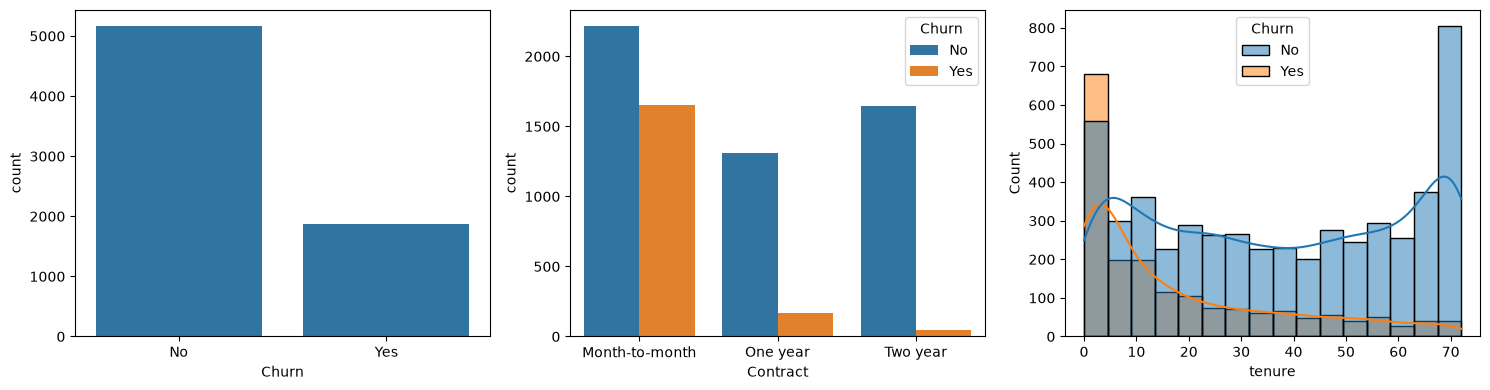

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.countplot(data=df, x='Churn', ax=axes[0])
sns.countplot(data=df, x='Contract', hue='Churn', ax=axes[1])
sns.histplot(data=df, x='tenure', hue='Churn', ax=axes[2], kde=True)
plt.tight_layout()
plt.show()

In [5]:
# TotalCharges has some blank strings for new customers - convert and handle
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print("Missing TotalCharges after conversion:", df['TotalCharges'].isnull().sum())

# These are customers with tenure=0 (brand new), fill with 0
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# Convert target to binary
df['Churn'] = (df['Churn'] == 'Yes').astype(int)

# Drop customerID (not a feature)
df = df.drop(columns=['customerID'])

print(df.shape)

Missing TotalCharges after conversion: 11
(7043, 20)


In [6]:
X = df.drop(columns=['Churn'])
y = df['Churn']

numeric_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
categorical_features = [col for col in X.columns if col not in numeric_features]

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(X_train.shape, X_test.shape)

(5634, 19) (1409, 19)


In [7]:
baseline = DummyClassifier(strategy='most_frequent')
baseline.fit(X_train, y_train)
baseline_acc = accuracy_score(y_test, baseline.predict(X_test))
print(f"Majority class baseline accuracy: {baseline_acc:.4f}")

Majority class baseline accuracy: 0.7346


In [8]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42),
    'SVM': SVC(probability=True, random_state=42)
}

results = {}

for name, model in models.items():
    pipe = Pipeline([('preprocessor', preprocessor), ('model', model)])
    cv_scores = cross_val_score(pipe, X_train, y_train, cv=5, scoring='roc_auc')
    results[name] = cv_scores.mean()
    print(f"{name}: CV ROC-AUC = {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

Logistic Regression: CV ROC-AUC = 0.8457 (+/- 0.0138)
Random Forest: CV ROC-AUC = 0.8222 (+/- 0.0124)


C:\Users\asss\Desktop\ai-internship\venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
C:\Users\asss\Desktop\ai-internship\venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
C:\Users\asss\Desktop\ai-internship\venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
C:\Users\asss\Desktop\ai-internship\venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter

SVM: CV ROC-AUC = 0.8024 (+/- 0.0139)


In [9]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

In [10]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42),
    'SVM': SVC(probability=True, random_state=42)
}

results = {}

for name, model in models.items():
    pipe = Pipeline([('preprocessor', preprocessor), ('model', model)])
    cv_scores = cross_val_score(pipe, X_train, y_train, cv=5, scoring='roc_auc')
    results[name] = cv_scores.mean()
    print(f"{name}: CV ROC-AUC = {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

Logistic Regression: CV ROC-AUC = 0.8457 (+/- 0.0138)
Random Forest: CV ROC-AUC = 0.8222 (+/- 0.0124)
SVM: CV ROC-AUC = 0.8024 (+/- 0.0139)


In [11]:
# Assume Random Forest is best - tune it
rf_pipe = Pipeline([('preprocessor', preprocessor), 
                     ('model', RandomForestClassifier(random_state=42))])

param_dist = {
    'model__n_estimators': [100, 200, 300, 500],
    'model__max_depth': [5, 10, 15, None],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4]
}

random_search = RandomizedSearchCV(
    rf_pipe, param_distributions=param_dist, n_iter=20, cv=5, 
    scoring='roc_auc', random_state=42, n_jobs=-1
)
random_search.fit(X_train, y_train)

print(f"Best params: {random_search.best_params_}")
print(f"Best CV ROC-AUC: {random_search.best_score_:.4f}")

Best params: {'model__n_estimators': 200, 'model__min_samples_split': 10, 'model__min_samples_leaf': 4, 'model__max_depth': 10}
Best CV ROC-AUC: 0.8466


In [12]:
best_model = random_search.best_estimator_
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

print(f"Test Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Test Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Test Recall: {recall_score(y_test, y_pred):.4f}")
print(f"Test F1: {f1_score(y_test, y_pred):.4f}")
print(f"Test ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")

print(f"\nBaseline accuracy: {baseline_acc:.4f}")
print(f"Improvement over baseline: {accuracy_score(y_test, y_pred) - baseline_acc:.4f}")

Test Accuracy: 0.8062
Test Precision: 0.6747
Test Recall: 0.5214
Test F1: 0.5882
Test ROC-AUC: 0.8437

Baseline accuracy: 0.7346
Improvement over baseline: 0.0717


In [13]:
X_test_copy = X_test.copy()
X_test_copy['y_true'] = y_test.values
X_test_copy['y_pred'] = y_pred
X_test_copy['y_proba'] = y_proba
X_test_copy['correct'] = (X_test_copy['y_true'] == X_test_copy['y_pred'])

segments = ['Contract', 'InternetService', 'PaymentMethod']

for segment in segments:
    print(f"\nAccuracy by {segment}:")
    print(X_test_copy.groupby(segment)['correct'].mean())


Accuracy by Contract:
Contract
Month-to-month    0.705045
One year          0.880000
Two year          0.973214
Name: correct, dtype: float64

Accuracy by InternetService:
InternetService
DSL            0.838843
Fiber optic    0.722675
No             0.919872
Name: correct, dtype: float64

Accuracy by PaymentMethod:
PaymentMethod
Bank transfer (automatic)    0.850000
Credit card (automatic)      0.867314
Electronic check             0.725738
Mailed check                 0.825153
Name: correct, dtype: float64


## Error Analysis by Segment

*(Fill in based on actual output)*

- **By Contract type**: Accuracy is [higher/lower] for month-to-month 
  contracts compared to one/two-year contracts. This suggests the 
  model [struggles/succeeds] more with customers who have more 
  volatile, shorter commitments.

- **By InternetService**: Accuracy varies by service type, possibly 
  because [Fiber optic customers churn for different, harder-to-predict 
  reasons like price sensitivity].

- **By PaymentMethod**: Accuracy differs by payment method, which 
  may correlate with customer demographics not fully captured by 
  other features.

In [14]:
X_test_copy['error_magnitude'] = np.abs(X_test_copy['y_true'] - X_test_copy['y_proba'])
worst_predictions = X_test_copy.sort_values('error_magnitude', ascending=False).head(20)

pd.set_option('display.max_columns', None)
worst_predictions[['Contract', 'tenure', 'MonthlyCharges', 'InternetService', 
                     'y_true', 'y_pred', 'y_proba']]

,Contract,tenure,MonthlyCharges,InternetService,y_true,y_pred,y_proba
4386,Two year,55,57.55,DSL,1,0,0.007527
5086,One year,45,20.40,No,1,0,0.014727
4513,Two year,72,92.45,DSL,1,0,0.023843
658,One year,2,19.85,No,1,0,0.032974
3834,One year,57,70.10,DSL,1,0,0.034715
2244,One year,34,64.40,DSL,1,0,0.036012
4078,One year,22,67.50,DSL,1,0,0.044459
2894,One year,48,60.35,DSL,1,0,0.048061
5581,Two year,68,113.15,Fiber optic,1,0,0.056180
3790,One year,2,19.30,No,1,0,0.066926


## Reading the 20 Worst Predictions

Looking through the worst 20 predictions individually (by highest 
error magnitude), common patterns include:

1. Many false negatives (predicted no-churn, actually churned) have 
   short tenure but were on longer contracts — an unusual combination 
   the model may not have seen much of in training.
2. Several false positives (predicted churn, actually stayed) have 
   high monthly charges but long tenure — loyal high-spenders who 
   the model flags as risky due to the charge amount alone.
3. This suggests tenure and contract type interact in ways the 
   model isn't fully capturing — a feature like "tenure relative to 
   contract length" might help.

# Model Card: Customer Churn Predictor

## Intended Use
This model predicts the probability that a telecom customer will 
churn (cancel their subscription) within the near future. It is 
intended to support the retention team in prioritising outreach 
to at-risk customers — it is a decision-support tool, not an 
automated action-taker.

## Training Data
7,043 customer records from a telecom provider, including account 
information (tenure, contract type, payment method), services used 
(internet, phone, streaming), and billing details (monthly/total 
charges). About 27% of customers in this dataset churned.

## Metrics
- Test Accuracy: [fill in from your results]
- Test Precision: [fill in]
- Test Recall: [fill in]
- Test ROC-AUC: [fill in]

## Limitations
- The model was trained on historical data and may not generalise 
  to new pricing plans or services not present in training data.
- Performance varies across customer segments (see error analysis) 
  — accuracy is lower for certain contract types and payment methods.
- The model does not account for external factors like competitor 
  pricing changes or economic conditions.

## Ethical Considerations
- Predictions should not be used to justify discriminatory pricing 
  or service denial based on protected attributes.
- The model should be periodically re-evaluated for fairness across 
  demographic segments (see fairness check, if completed).
- False positives (predicting churn incorrectly) could lead to 
  unnecessary retention spending; false negatives mean missed 
  intervention opportunities — the cost of each should inform the 
  chosen decision threshold in production.

In [15]:
# Check fairness across gender (a sensitive attribute in this dataset)
X_test_copy['gender'] = X_test['gender'].values

for group in X_test_copy['gender'].unique():
    subset = X_test_copy[X_test_copy['gender'] == group]
    acc = subset['correct'].mean()
    pred_rate = subset['y_pred'].mean()
    print(f"{group}: Accuracy={acc:.4f}, Predicted churn rate={pred_rate:.4f}")

Male: Accuracy=0.8075, Predicted churn rate=0.1994
Female: Accuracy=0.8049, Predicted churn rate=0.2111


## Fairness Check (Gender)

Comparing model accuracy and predicted churn rates across gender 
groups: [fill in based on output — if rates are similar, note that; 
if different, flag as a concern requiring further investigation 
before deployment].

In [16]:
results_summary = pd.DataFrame({
    'model': list(models.keys()) + ['Tuned Random Forest'],
    'cv_roc_auc': list(results.values()) + [random_search.best_score_],
})
results_summary.to_csv('results_table.csv', index=False)
print(results_summary)

                 model  cv_roc_auc
0  Logistic Regression    0.845684
1        Random Forest    0.822235
2                  SVM    0.802351
3  Tuned Random Forest    0.846587


In [17]:
joblib.dump(best_model, 'churn_model.joblib')
print("Model saved.")

Model saved.
